# Notebook 3 — LSTM Time-Series Model
Trains LSTM on 14-day sliding windows → adds lstm_disruption_prob column → saves final_dataset.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

DATA_DIR   = '../datasets/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print('Imports done.')

TensorFlow: 2.21.0
Imports done.


In [2]:
df = pd.read_csv(DATA_DIR + 'merged_dataset.csv', parse_dates=['order_date'])
df = df.sort_values(['supplier_city','order_date']).reset_index(drop=True)
print(f'Loaded merged_dataset: {df.shape}')

Loaded merged_dataset: (8000, 36)


In [3]:
# LSTM features — includes weather_anomaly_score from Isolation Forest
LSTM_FEATURES = [
    'distance_km', 'promised_delivery_days', 'quantity_units',
    'rainfall_mm', 'temperature_celsius', 'wind_speed_kmh',
    'severity_score', 'weather_anomaly_score',
    'sentiment_score', 'disruption_signal',
    'composite_risk_score', 'delivery_reliability_score',
    'regional_risk_index', 'historical_disruption_count',
    'rolling_7d_delay', 'rolling_14d_delay', 'lag1_delay', 'lag2_delay',
    'transport_mode_enc', 'product_category_enc', 'supplier_city_enc'
]

SEQ_LEN    = 14
N_FEATURES = len(LSTM_FEATURES)
print(f'LSTM features: {N_FEATURES}  |  Sequence length: {SEQ_LEN}')

LSTM features: 21  |  Sequence length: 14


In [4]:
# Normalize
scaler = MinMaxScaler()
df[LSTM_FEATURES] = scaler.fit_transform(df[LSTM_FEATURES])

joblib.dump(scaler, MODELS_DIR + 'scaler.pkl')
print('Scaler fitted and saved.')

Scaler fitted and saved.


In [5]:
# Build 14-day sliding window sequences per city
def make_sequences(group_df, seq_len, features, target_col):
    X, y, indices = [], [], []
    vals = group_df[features].values
    tgt  = group_df[target_col].values
    idx  = group_df.index.values
    for i in range(len(vals) - seq_len):
        X.append(vals[i: i+seq_len])
        y.append(tgt[i+seq_len])
        indices.append(idx[i+seq_len])
    return np.array(X), np.array(y), np.array(indices)

X_all, y_all, idx_all = [], [], []
for city, grp in df.groupby('supplier_city'):
    Xc, yc, ic = make_sequences(grp, SEQ_LEN, LSTM_FEATURES, 'disruption_label')
    if len(Xc) > 0:
        X_all.append(Xc); y_all.append(yc); idx_all.append(ic)

X_all   = np.concatenate(X_all, axis=0)
y_all   = np.concatenate(y_all, axis=0)
idx_all = np.concatenate(idx_all, axis=0)

print(f'Sequences shape: {X_all.shape}  |  Labels: {y_all.shape}')
print(f'Disruption rate in sequences: {y_all.mean():.3f}')

Sequences shape: (7790, 14, 21)  |  Labels: (7790,)
Disruption rate in sequences: 0.505


In [6]:
# 80/20 positional split
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
idx_train, idx_test = idx_all[:split], idx_all[split:]

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (6232, 14, 21)  |  Test: (1558, 14, 21)


In [7]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, N_FEATURES)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,977 (136.63 KB)

 Trainable params: 34,977 (136.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train LSTM — EarlyStopping stops if val_loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5078 - loss: 0.6939 - val_accuracy: 0.5326 - val_loss: 0.6894
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5201 - loss: 0.6918 - val_accuracy: 0.5305 - val_loss: 0.6879
Epoch 3/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5471 - loss: 0.6867 - val_accuracy: 0.5070 - val_loss: 0.6955
Epoch 4/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5941 - loss: 0.6712 - val_accuracy: 0.6599 - val_loss: 0.6519
Epoch 5/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6772 - loss: 0.6140 - val_accuracy: 0.7027 - val_loss: 0.5751
Epoch 6/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7134 - loss: 0.5392 - val_accuracy: 0.7187 - val_loss: 0.5124
Epoch 7/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7261 - loss: 0.4969 - val_accuracy: 0.7219 - val_loss: 0.4849
Epoch 8/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7502 - loss: 0.4736 - val_accuracy: 0.7123 - v

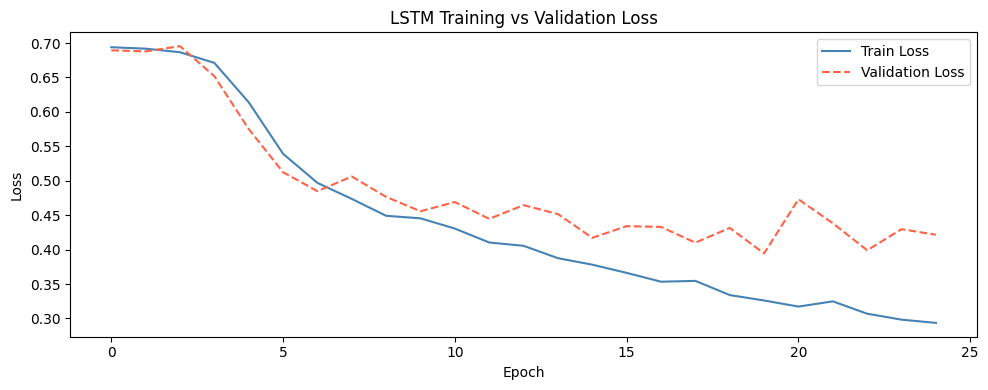

In [9]:
# Training vs validation loss curves
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'],     label='Train Loss',      color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.tight_layout(); plt.show()

In [10]:
# Evaluate LSTM on test set
y_prob_test = model.predict(X_test, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

print('── LSTM Test Evaluation ──')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_test, zero_division=0):.4f}')
print(f'  AUC-ROC  : {roc_auc_score(y_test, y_prob_test):.4f}')

── LSTM Test Evaluation ──
  Accuracy : 0.7991
  F1-Score : 0.8060
  AUC-ROC  : 0.9042


In [11]:
# Add lstm_disruption_prob back into the full dataset
# Run prediction on ALL sequences (train + test) to get probabilities for every row
all_probs = model.predict(X_all, verbose=0).flatten()

# Map probabilities back to dataframe rows using saved indices
prob_series = pd.Series(all_probs, index=idx_all)
df['lstm_disruption_prob'] = prob_series

# Rows that didn't get a sequence (first 14 rows per city) get city median
city_median = df.groupby('supplier_city_enc')['lstm_disruption_prob'].transform('median')
df['lstm_disruption_prob'] = df['lstm_disruption_prob'].fillna(city_median).fillna(0.5)

print(f'lstm_disruption_prob added. Non-null: {df["lstm_disruption_prob"].notna().sum()}')
print(f'Sample values: {df["lstm_disruption_prob"].describe().round(3).to_dict()}')

lstm_disruption_prob added. Non-null: 8000
Sample values: {'count': 8000.0, 'mean': 0.495, 'std': 0.375, 'min': 0.001, '25%': 0.117, '50%': 0.453, '75%': 0.913, 'max': 1.0}


In [12]:
# Save LSTM model and final dataset
model.save(MODELS_DIR + 'lstm_model.h5')
print('lstm_model.h5 saved.')

df.to_csv(DATA_DIR + 'final_dataset.csv', index=False)
print('final_dataset.csv saved.')
print(f'Final dataset shape: {df.shape}')
print('\n✅ Notebook 3 (LSTM) complete.')

lstm_model.h5 saved.
final_dataset.csv saved.
Final dataset shape: (8000, 37)

✅ Notebook 3 (LSTM) complete.
